# Auditoría puente DAGMA/CVC vs tiles Sit 2

Cruce externo ligero entre tiles de Sit 2 y mediciones oficiales DAGMA/CVC. No entrena modelos y no valida CLIP como predictor; solo revisa coherencia espacial-temporal entre pseudo-labels satelitales y observaciones cercanas.

## Criterio metodológico

- Unidad satelital: tile Sentinel-2 de Sit 2.
- Unidad observada: medición horaria DAGMA/CVC agregada por día.
- Cruce espacial: estación más cercana que mida el contaminante.
- Cruce temporal: día exacto, ±1 día y ±3 días.
- Salida esperada: tablas y figuras de coherencia, no predicción directa.

In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 10

In [2]:
RAIZ = Path.cwd().resolve()
while not ((RAIZ / ".git").exists() or (RAIZ / "pyproject.toml").exists()) and RAIZ.parent != RAIZ:
    RAIZ = RAIZ.parent

KAGGLE_INPUT = Path("/kaggle/input/datasets/juanjoseorozcolopez/geovision-fuentes")
if KAGGLE_INPUT.exists():
    RAIZ_DATOS = KAGGLE_INPUT
    OUT = Path("/kaggle/working/auditoria_puente_dagma")
else:
    RAIZ_DATOS = RAIZ
    OUT = Path("auditoria_puente_dagma_local_output/auditoria_puente_dagma")

RUTA_TILES = RAIZ_DATOS / "data" / "tiles_sit2" / "tiles_meta.parquet"
RUTA_DAGMA = RAIZ_DATOS / "dagma" / "dagma_cvc_horario_raw.parquet"
RUTA_ESTACIONES = RAIZ_DATOS / "dagma" / "estaciones_metadata.csv"

OUT.mkdir(parents=True, exist_ok=True)
(OUT / "tablas").mkdir(exist_ok=True)
(OUT / "figuras").mkdir(exist_ok=True)

print(f"Raíz datos: {RAIZ_DATOS}")
print(f"Salida: {OUT}")

Raíz datos: /home/yeigen/Documents/proyecto-3
Salida: auditoria_puente_dagma_local_output/auditoria_puente_dagma


In [3]:
meta = pd.read_parquet(RUTA_TILES)
dagma = pd.read_parquet(RUTA_DAGMA)
estaciones = pd.read_csv(RUTA_ESTACIONES)

print(f"Tiles: {meta.shape}")
print(f"DAGMA/CVC: {dagma.shape}")
print(f"Estaciones: {estaciones.shape}")
print(meta.head(3).to_string(index=False))

Tiles: (5000, 22)
DAGMA/CVC: (107291, 14)
Estaciones: (10, 8)
                 clase                                time_s2      lat        lon     ndvi      ndbi  scl_pct      no2  so2  o3                                                                  texto   era5_T2m  era5_Td2m  era5_u10  era5_v10   era5_BLH  era5_RH850   era5_psurf  era5_precip  modis_AOD_047  modis_AOD_055  modis_WV
contaminacion_alta_NO2 20230829T153619_20230829T153712_T18NUJ 3.512862 -76.313051 0.601409 -0.100395 0.944092 0.000078  NaN NaN Zona urbana con NO2 alto (7.80e-05 mol/m2), trafico vehicular intenso. 297.228943 292.810974 -0.190445 -1.326828 692.154663   87.927605 86080.359375     0.000043            NaN            NaN    0.4025
contaminacion_alta_NO2 20240220T153621_20240220T153623_T18NUJ 3.556161 -76.490109 0.425136 -0.048721 1.000000 0.000080  NaN NaN Zona urbana con NO2 alto (8.03e-05 mol/m2), trafico vehicular intenso. 296.283142 293.837616  0.792231 -0.757112 751.030029   92.931656 86194.250000  

In [4]:
CONTAMINANTES = ["NO2", "SO2", "O3"]
CLASE_OBJETIVO = {
    "NO2": "contaminacion_alta_NO2",
    "SO2": "contaminacion_alta_SO2",
    "O3": "ozono_anomalo",
}
VENTANAS_DIAS = [0, 1, 3]

tiles = meta.copy()
tiles["tile_id"] = np.arange(len(tiles))
tiles["fecha_tile"] = pd.to_datetime(tiles["time_s2"].astype(str).str.extract(r"(\d{8})", expand=False), format="%Y%m%d", errors="coerce").dt.floor("D")
tiles["anio"] = tiles["fecha_tile"].dt.year

obs = dagma.rename(columns={
    "med_fecha_inicio": "fecha",
    "msfl_code": "contaminante",
    "med_concentracion_estandar": "valor",
}).copy()
obs["fecha"] = pd.to_datetime(obs["fecha"], errors="coerce")
obs["valor"] = pd.to_numeric(obs["valor"], errors="coerce")
obs = obs[obs["contaminante"].isin(CONTAMINANTES)]
obs = obs.dropna(subset=["fecha", "nombre_est", "contaminante", "valor"])
obs = obs[np.isfinite(obs["valor"])]
obs = obs[obs["valor"] >= 0]
obs["fecha_dia"] = obs["fecha"].dt.floor("D")

diario = (
    obs.groupby(["nombre_est", "contaminante", "fecha_dia"], as_index=False)
    .agg(valor_medio=("valor", "mean"), valor_mediano=("valor", "median"), n_horas=("valor", "size"))
)

print(tiles.groupby("clase").size().to_string())
print(diario.groupby(["contaminante", "nombre_est"]).size().unstack(fill_value=0).to_string())

clase
contaminacion_alta_NO2    1000
contaminacion_alta_SO2    1000
ozono_anomalo             1000
suelo_urbano              1000
vegetacion_densa          1000
nombre_est    BASE AÉREA  CAÑAVERALEJO  COMPARTIR  ERA OBRERO  ESTACIÓN YUMBO  LA ERMITA  LA FLORA  PANCE  TRANSITORIA-NAVARRO  UNIVERSIDAD DEL VALLE
contaminante                                                                                                                                         
NO2                    0             0          0           0             331          0         0      0                    0                      0
O3                   507             0        458         422             859          0       342    395                  221                    412
SO2                  441           370          0           0             629        448       236      0                  162                      0


In [5]:
def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0088
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))

est_base = estaciones[["nombre_est", "municipio", "latitud", "longitud"]].drop_duplicates().copy()
cobertura_estacion = diario.groupby(["contaminante", "nombre_est"], as_index=False).agg(n_dias=("fecha_dia", "nunique"))
est_por_contaminante = cobertura_estacion.merge(est_base, on="nombre_est", how="left")

pares = []
for contaminante in CONTAMINANTES:
    est = est_por_contaminante[est_por_contaminante["contaminante"] == contaminante].dropna(subset=["latitud", "longitud"]).copy()
    lat_tiles = tiles["lat"].to_numpy()[:, None]
    lon_tiles = tiles["lon"].to_numpy()[:, None]
    lat_est = est["latitud"].to_numpy()[None, :]
    lon_est = est["longitud"].to_numpy()[None, :]
    distancias = haversine_km(lat_tiles, lon_tiles, lat_est, lon_est)
    idx = distancias.argmin(axis=1)
    tmp = tiles[["tile_id", "clase", "fecha_tile", "anio", "lat", "lon", "ndvi", "ndbi", "scl_pct"]].copy()
    tmp["contaminante"] = contaminante
    tmp["estacion_cercana"] = est.iloc[idx]["nombre_est"].to_numpy()
    tmp["municipio_estacion"] = est.iloc[idx]["municipio"].to_numpy()
    tmp["distancia_km"] = distancias[np.arange(len(tmp)), idx]
    tmp["n_dias_estacion"] = est.iloc[idx]["n_dias"].to_numpy()
    pares.append(tmp)

tile_estacion = pd.concat(pares, ignore_index=True)
tile_estacion.to_csv(OUT / "tablas" / "tiles_estacion_mas_cercana_por_contaminante.csv", index=False)
tile_estacion.head(10)

,tile_id,clase,fecha_tile,anio,lat,lon,ndvi,ndbi,scl_pct,contaminante,estacion_cercana,municipio_estacion,distancia_km,n_dias_estacion
0,0,contaminacion_alta_NO2,2023-08-29,2023,3.512862,-76.313051,0.601409,-0.100395,0.944092,NO2,ESTACIÓN YUMBO,Yumbo,20.927033,331
1,1,contaminacion_alta_NO2,2024-02-20,2024,3.556161,-76.490109,0.425136,-0.048721,1.000000,NO2,ESTACIÓN YUMBO,Yumbo,2.548690,331
2,2,contaminacion_alta_NO2,2021-09-03,2021,3.375150,-76.571766,0.706977,-0.193641,1.000000,NO2,ESTACIÓN YUMBO,Yumbo,24.442343,331
3,3,contaminacion_alta_NO2,2024-08-28,2024,3.372904,-76.570419,0.662837,-0.145759,1.000000,NO2,ESTACIÓN YUMBO,Yumbo,24.619279,331
4,4,contaminacion_alta_NO2,2023-08-29,2023,3.503250,-76.542391,0.683332,-0.190358,1.000000,NO2,ESTACIÓN YUMBO,Yumbo,10.269830,331
5,5,contaminacion_alta_NO2,2024-09-12,2024,3.425636,-76.512477,0.147254,0.089130,1.000000,NO2,ESTACIÓN YUMBO,Yumbo,17.250299,331
6,6,contaminacion_alta_NO2,2024-11-06,2024,3.415664,-76.490558,0.168670,0.131859,1.000000,NO2,ESTACIÓN YUMBO,Yumbo,18.170816,331
7,7,contaminacion_alta_NO2,2024-10-17,2024,3.415574,-76.521011,0.212524,0.107743,1.000000,NO2,ESTACIÓN YUMBO,Yumbo,18.512587,331
8,8,contaminacion_alta_NO2,2023-01-26,2023,3.373893,-76.541044,0.469084,-0.058151,1.000000,NO2,ESTACIÓN YUMBO,Yumbo,23.520022,331
9,9,contaminacion_alta_NO2,2021-10-13,2021,3.425546,-76.540684,0.187093,0.093613,0.952148,NO2,ESTACIÓN YUMBO,Yumbo,17.990043,331


In [6]:
diario_idx = diario.set_index(["nombre_est", "contaminante", "fecha_dia"]).sort_index()
registros = []

for fila in tile_estacion.itertuples(index=False):
    for ventana in VENTANAS_DIAS:
        fechas = pd.date_range(fila.fecha_tile - pd.Timedelta(days=ventana), fila.fecha_tile + pd.Timedelta(days=ventana), freq="D")
        try:
            sub = diario_idx.loc[(fila.estacion_cercana, fila.contaminante)].reindex(fechas)
        except KeyError:
            sub = pd.DataFrame(columns=["valor_medio", "valor_mediano", "n_horas"])
        valores = pd.to_numeric(sub.get("valor_medio", pd.Series(dtype=float)), errors="coerce").dropna()
        horas = pd.to_numeric(sub.get("n_horas", pd.Series(dtype=float)), errors="coerce").fillna(0)
        registros.append({
            "tile_id": fila.tile_id,
            "clase": fila.clase,
            "fecha_tile": fila.fecha_tile,
            "anio": fila.anio,
            "contaminante": fila.contaminante,
            "ventana_dias": ventana,
            "estacion_cercana": fila.estacion_cercana,
            "municipio_estacion": fila.municipio_estacion,
            "distancia_km": fila.distancia_km,
            "valor_dagma": valores.mean() if len(valores) else np.nan,
            "dias_con_dato": int(len(valores)),
            "horas_con_dato": int(horas.sum()) if len(horas) else 0,
        })

cruce = pd.DataFrame(registros)
cruce.to_csv(OUT / "tablas" / "cruce_tiles_dagma_por_ventana.csv", index=False)
print(cruce.shape)
cruce.head(10)

(45000, 12)


,tile_id,clase,fecha_tile,anio,contaminante,ventana_dias,estacion_cercana,municipio_estacion,distancia_km,valor_dagma,dias_con_dato,horas_con_dato
0,0,contaminacion_alta_NO2,2023-08-29,2023,NO2,0,ESTACIÓN YUMBO,Yumbo,20.927033,NaN,0,0
1,0,contaminacion_alta_NO2,2023-08-29,2023,NO2,1,ESTACIÓN YUMBO,Yumbo,20.927033,NaN,0,0
2,0,contaminacion_alta_NO2,2023-08-29,2023,NO2,3,ESTACIÓN YUMBO,Yumbo,20.927033,NaN,0,0
3,1,contaminacion_alta_NO2,2024-02-20,2024,NO2,0,ESTACIÓN YUMBO,Yumbo,2.548690,NaN,0,0
4,1,contaminacion_alta_NO2,2024-02-20,2024,NO2,1,ESTACIÓN YUMBO,Yumbo,2.548690,NaN,0,0
5,1,contaminacion_alta_NO2,2024-02-20,2024,NO2,3,ESTACIÓN YUMBO,Yumbo,2.548690,NaN,0,0
6,2,contaminacion_alta_NO2,2021-09-03,2021,NO2,0,ESTACIÓN YUMBO,Yumbo,24.442343,NaN,0,0
7,2,contaminacion_alta_NO2,2021-09-03,2021,NO2,1,ESTACIÓN YUMBO,Yumbo,24.442343,5.7800,1,12
8,2,contaminacion_alta_NO2,2021-09-03,2021,NO2,3,ESTACIÓN YUMBO,Yumbo,24.442343,6.9825,3,60
9,3,contaminacion_alta_NO2,2024-08-28,2024,NO2,0,ESTACIÓN YUMBO,Yumbo,24.619279,NaN,0,0


In [7]:
resumen = (
    cruce.groupby(["contaminante", "ventana_dias", "clase"], as_index=False)
    .agg(
        n_tiles=("tile_id", "nunique"),
        n_con_dagma=("valor_dagma", lambda s: int(s.notna().sum())),
        dagma_media=("valor_dagma", "mean"),
        dagma_mediana=("valor_dagma", "median"),
        dagma_p75=("valor_dagma", lambda s: s.quantile(0.75)),
        distancia_mediana_km=("distancia_km", "median"),
        distancia_p75_km=("distancia_km", lambda s: s.quantile(0.75)),
    )
)
resumen["cobertura_dagma"] = resumen["n_con_dagma"] / resumen["n_tiles"]
resumen.to_csv(OUT / "tablas" / "resumen_clase_contaminante_ventana.csv", index=False)
resumen.sort_values(["contaminante", "ventana_dias", "dagma_mediana"], ascending=[True, True, False]).to_string(index=False)

'contaminante  ventana_dias                  clase  n_tiles  n_con_dagma  dagma_media  dagma_mediana  dagma_p75  distancia_mediana_km  distancia_p75_km  cobertura_dagma\n         NO2             0          ozono_anomalo     1000            2    20.545455      20.545455  20.545455             18.650735         25.211494            0.002\n         NO2             0 contaminacion_alta_NO2     1000           50    15.083808      14.880952  14.880952             13.660114         18.312166            0.050\n         NO2             0 contaminacion_alta_SO2     1000          141    14.044935      14.880952  14.880952             18.371079         25.150597            0.141\n         NO2             0           suelo_urbano     1000          112    10.406046      11.580000  14.880952             14.444590         17.608952            0.112\n         NO2             0       vegetacion_densa     1000          107    10.113356      11.580000  14.880952             19.027765         26.721826    

In [8]:
comparaciones = []
for contaminante, clase_objetivo in CLASE_OBJETIVO.items():
    for ventana in VENTANAS_DIAS:
        sub = cruce[(cruce["contaminante"] == contaminante) & (cruce["ventana_dias"] == ventana)].dropna(subset=["valor_dagma"]).copy()
        objetivo = sub[sub["clase"] == clase_objetivo]["valor_dagma"]
        resto = sub[sub["clase"] != clase_objetivo]["valor_dagma"]
        if len(objetivo) and len(resto):
            med_obj = objetivo.median()
            med_resto = resto.median()
            percentil_obj = (sub["valor_dagma"] <= med_obj).mean()
            direccion = "coherente" if med_obj >= med_resto else "débil o inversa"
        else:
            med_obj = np.nan
            med_resto = np.nan
            percentil_obj = np.nan
            direccion = "sin datos suficientes"
        comparaciones.append({
            "contaminante": contaminante,
            "clase_objetivo": clase_objetivo,
            "ventana_dias": ventana,
            "n_objetivo": int(len(objetivo)),
            "n_resto": int(len(resto)),
            "mediana_objetivo": med_obj,
            "mediana_resto": med_resto,
            "diferencia_mediana": med_obj - med_resto if pd.notna(med_obj) and pd.notna(med_resto) else np.nan,
            "percentil_mediana_objetivo": percentil_obj,
            "lectura": direccion,
        })

comparaciones = pd.DataFrame(comparaciones)
comparaciones.to_csv(OUT / "tablas" / "comparacion_clases_objetivo_vs_resto.csv", index=False)
comparaciones.to_string(index=False)

'contaminante         clase_objetivo  ventana_dias  n_objetivo  n_resto  mediana_objetivo  mediana_resto  diferencia_mediana  percentil_mediana_objetivo         lectura\n         NO2 contaminacion_alta_NO2             0          50      362         14.880952      13.315476            1.565476                    0.837379       coherente\n         NO2 contaminacion_alta_NO2             1          81      393         10.472917      10.773291           -0.300374                    0.485232 débil o inversa\n         NO2 contaminacion_alta_NO2             3          81      393          9.543809      10.259451           -0.715642                    0.485232 débil o inversa\n         SO2 contaminacion_alta_SO2             0         141      399          6.043810       9.894000           -3.850190                    0.422222 débil o inversa\n         SO2 contaminacion_alta_SO2             1         146      448          7.657062      10.123634           -2.466572                    0.441077 dé

/tmp/ipykernel_51050/284163684.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=clases, showfliers=False)


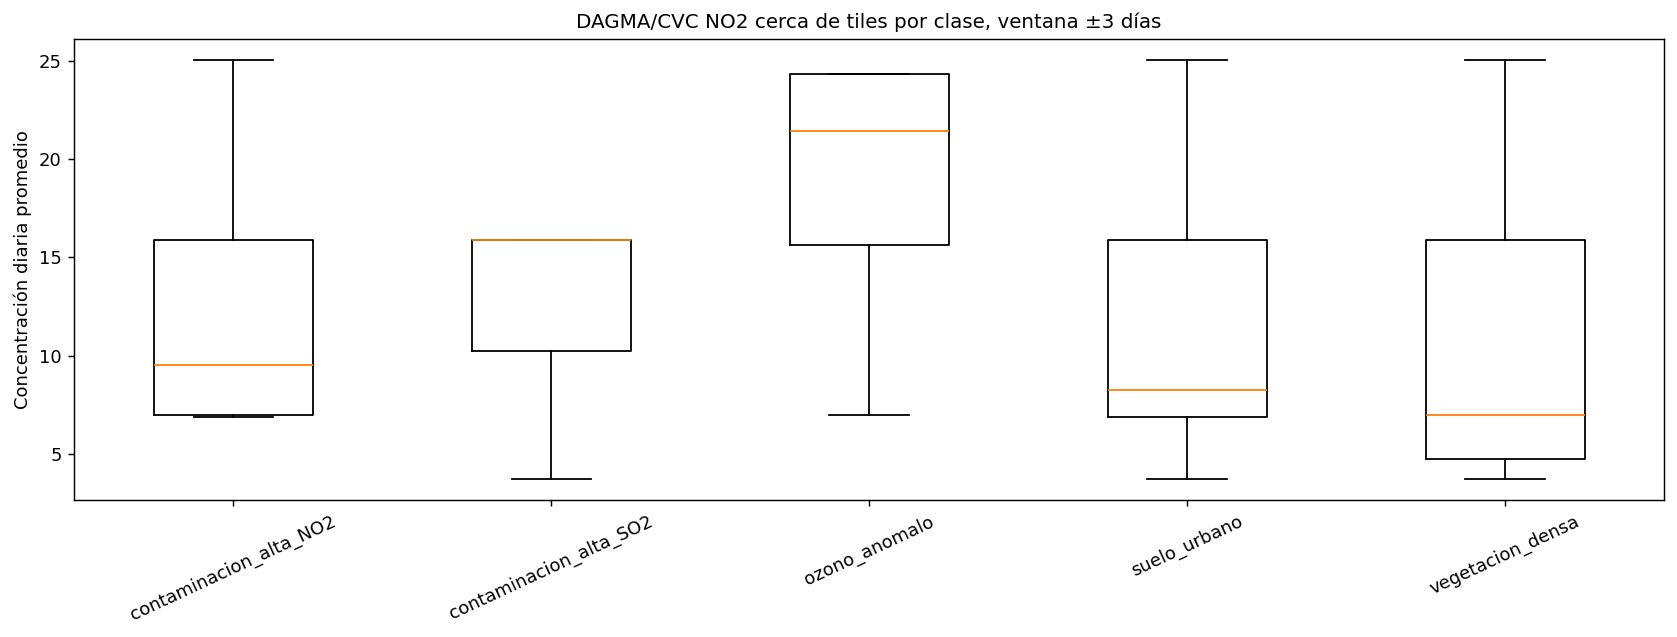

/tmp/ipykernel_51050/284163684.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=clases, showfliers=False)


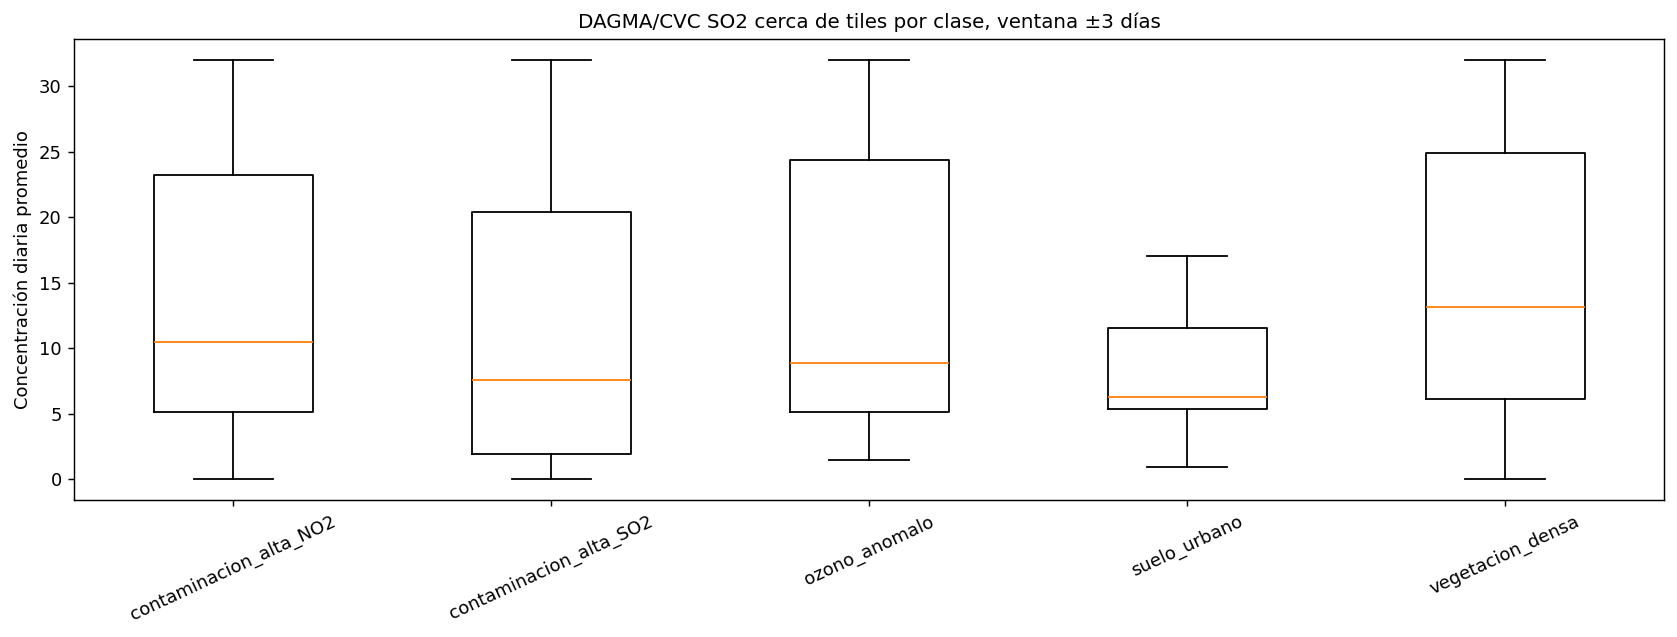

/tmp/ipykernel_51050/284163684.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=clases, showfliers=False)


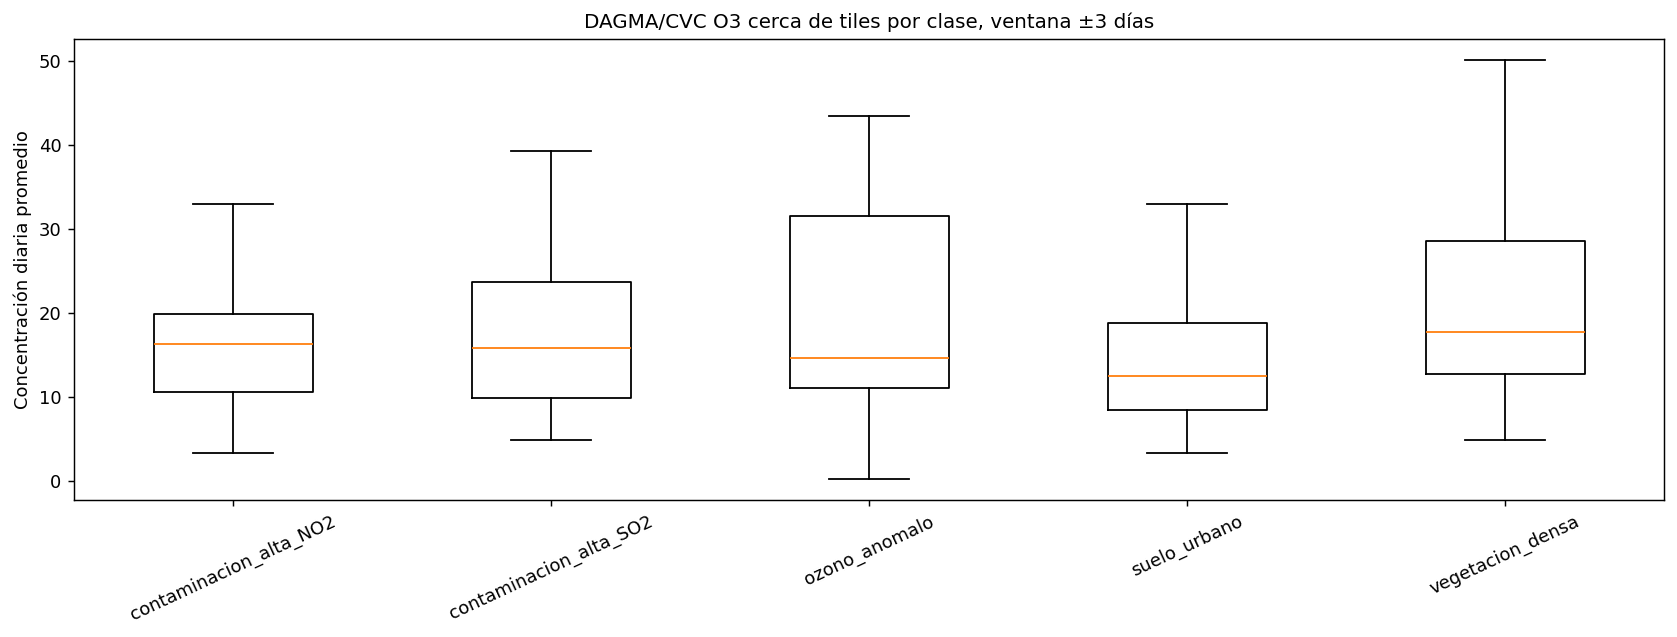

In [9]:
for contaminante in CONTAMINANTES:
    sub = cruce[(cruce["contaminante"] == contaminante) & (cruce["ventana_dias"] == 3)].dropna(subset=["valor_dagma"]).copy()
    if sub.empty:
        continue
    clases = sorted(sub["clase"].unique())
    datos = [sub[sub["clase"] == clase]["valor_dagma"] for clase in clases]
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.boxplot(datos, labels=clases, showfliers=False)
    ax.set_title(f"DAGMA/CVC {contaminante} cerca de tiles por clase, ventana ±3 días")
    ax.set_ylabel("Concentración diaria promedio")
    ax.tick_params(axis="x", rotation=25)
    fig.tight_layout()
    fig.savefig(OUT / "figuras" / f"boxplot_dagma_{contaminante}_por_clase.png", bbox_inches="tight")
    plt.show()

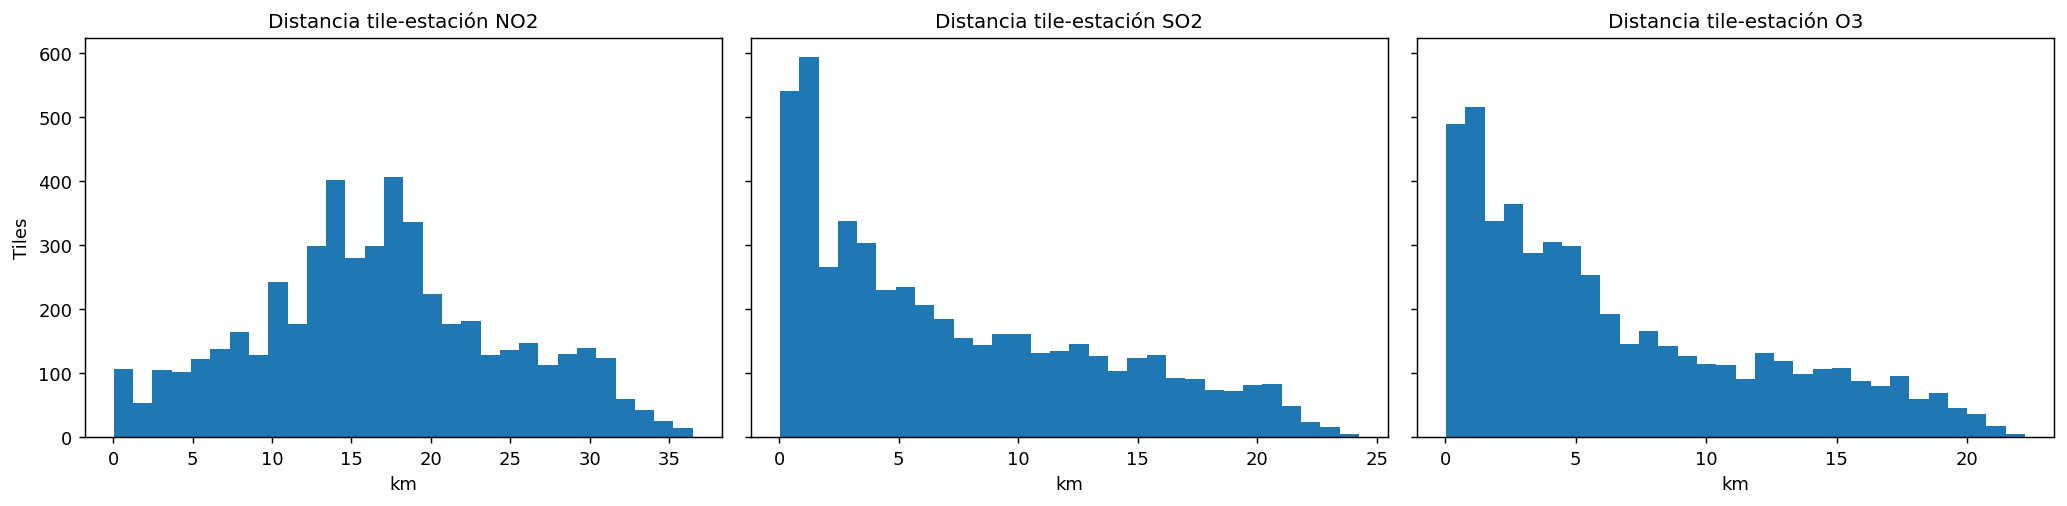

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, contaminante in zip(axes, CONTAMINANTES):
    sub = tile_estacion[tile_estacion["contaminante"] == contaminante]
    ax.hist(sub["distancia_km"], bins=30)
    ax.set_title(f"Distancia tile-estación {contaminante}")
    ax.set_xlabel("km")
axes[0].set_ylabel("Tiles")
fig.tight_layout()
fig.savefig(OUT / "figuras" / "distancia_tile_estacion_por_contaminante.png", bbox_inches="tight")
plt.show()

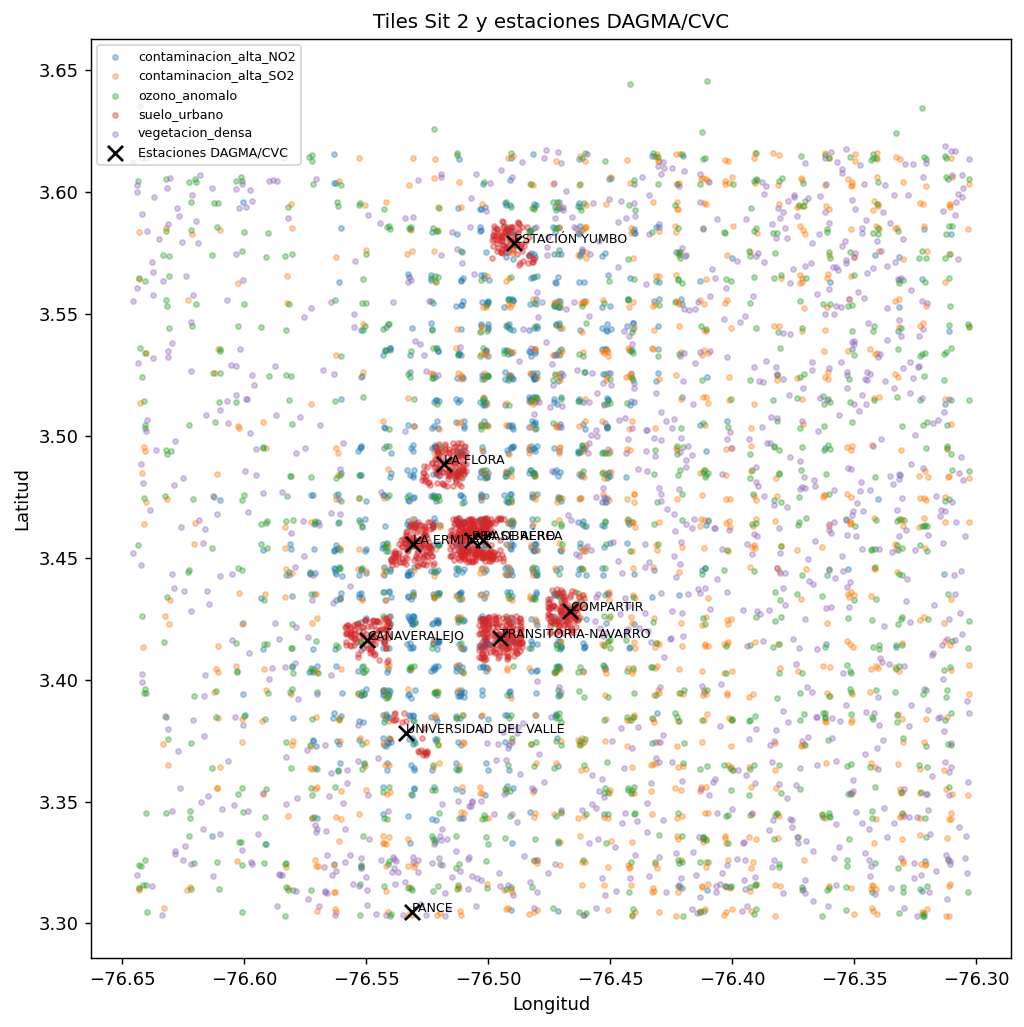

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))
for clase, sub in tiles.groupby("clase"):
    ax.scatter(sub["lon"], sub["lat"], s=8, alpha=0.35, label=clase)
ax.scatter(estaciones["longitud"], estaciones["latitud"], s=70, c="black", marker="x", label="Estaciones DAGMA/CVC")
for fila in estaciones.itertuples(index=False):
    ax.text(fila.longitud, fila.latitud, fila.nombre_est, fontsize=7)
ax.set_title("Tiles Sit 2 y estaciones DAGMA/CVC")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend(loc="best", fontsize=7)
fig.tight_layout()
fig.savefig(OUT / "figuras" / "mapa_tiles_estaciones_dagma.png", bbox_inches="tight")
plt.show()

In [12]:
veredicto = {
    "n_tiles": int(len(tiles)),
    "n_observaciones_dagma_filtradas": int(len(obs)),
    "n_dias_dagma": int(diario["fecha_dia"].nunique()),
    "ventanas_dias": VENTANAS_DIAS,
    "comparaciones": comparaciones.replace({np.nan: None}).to_dict(orient="records"),
    "nota": "Auditoría externa de coherencia. No constituye validación predictiva directa de CLIP ni de los embeddings.",
}
with open(OUT / "resumen_auditoria_puente_dagma.json", "w", encoding="utf-8") as f:
    json.dump(veredicto, f, ensure_ascii=False, indent=2)

print(json.dumps(veredicto, ensure_ascii=False, indent=2))

{
  "n_tiles": 5000,
  "n_observaciones_dagma_filtradas": 107291,
  "n_dias_dagma": 1640,
  "ventanas_dias": [
    0,
    1,
    3
  ],
  "comparaciones": [
    {
      "contaminante": "NO2",
      "clase_objetivo": "contaminacion_alta_NO2",
      "ventana_dias": 0,
      "n_objetivo": 50,
      "n_resto": 362,
      "mediana_objetivo": 14.880952380952381,
      "mediana_resto": 13.31547619047619,
      "diferencia_mediana": 1.5654761904761916,
      "percentil_mediana_objetivo": 0.837378640776699,
      "lectura": "coherente"
    },
    {
      "contaminante": "NO2",
      "clase_objetivo": "contaminacion_alta_NO2",
      "ventana_dias": 1,
      "n_objetivo": 81,
      "n_resto": 393,
      "mediana_objetivo": 10.472916666666668,
      "mediana_resto": 10.773290598290599,
      "diferencia_mediana": -0.30037393162393045,
      "percentil_mediana_objetivo": 0.48523206751054854,
      "lectura": "débil o inversa"
    },
    {
      "contaminante": "NO2",
      "clase_objetivo": "contam

## Lectura sugerida

- Si la clase objetivo tiene mediana DAGMA/CVC mayor que el resto para su contaminante, el muestreo es externamente coherente.
- Si la cobertura temporal es baja, reportar la limitación antes que forzar una conclusión.
- Si la señal sale débil o inversa, revisar si la distancia a estaciones, el desfase temporal o la cobertura por contaminante explican el resultado.